# EDA Practice
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

First-look EDA workflow on a synthetic car insurance claims dataset.

### Main goals:

- Run a full describe/info/missing-value check on a new dataset.
- Examine numeric distributions and categorical counts.
- Build and interpret a correlation heatmap.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', font_scale=0.95)

## Building the Dataset

In [2]:
np.random.seed(11)
n = 400

vehicle_age   = np.random.exponential(4, n).clip(0, 20)
driver_age    = np.random.normal(40, 12, n).clip(18, 75)
annual_mileage= np.random.normal(12000, 4000, n).clip(1000, 35000)
vehicle_type  = np.random.choice(['Sedan', 'SUV', 'Hatchback', 'Truck'], n, p=[0.35, 0.30, 0.25, 0.10])
region        = np.random.choice(['Urban', 'Suburban', 'Rural'], n, p=[0.5, 0.3, 0.2])

claim_prob = 0.1 + 0.02*vehicle_age + 0.00002*annual_mileage - 0.002*(driver_age - 40).clip(0, None)
claim_filed = np.random.binomial(1, claim_prob.clip(0.02, 0.9))

df = pd.DataFrame({
    'vehicle_age': vehicle_age.round(1),
    'driver_age': driver_age.round(0),
    'annual_mileage': annual_mileage.round(0),
    'vehicle_type': vehicle_type,
    'region': region,
    'claim_filed': claim_filed
})
df.loc[[5, 22, 88], 'annual_mileage'] = np.nan

df.head()

,vehicle_age,driver_age,annual_mileage,vehicle_type,region,claim_filed
0,0.8,49.0,9137.0,Hatchback,Urban,0
1,0.1,36.0,7176.0,Truck,Urban,0
2,2.5,18.0,16588.0,Truck,Suburban,0
3,5.2,26.0,15512.0,SUV,Urban,0
4,2.2,30.0,8606.0,SUV,Suburban,0


## info() and describe()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vehicle_age     400 non-null    float64
 1   driver_age      400 non-null    float64
 2   annual_mileage  397 non-null    float64
 3   vehicle_type    400 non-null    object 
 4   region          400 non-null    object 
 5   claim_filed     400 non-null    int32  
dtypes: float64(3), int32(1), object(2)
memory usage: 17.3+ KB


**Observation:**
annual_mileage at 397/400 non-null matches the 3 rows deliberately left blank. vehicle_type and region need encoding before any model.

In [4]:
df.describe().round(1)

,vehicle_age,driver_age,annual_mileage,claim_filed
count,400.0,400.0,397.0,400.0
mean,4.0,40.3,12032.3,0.4
std,3.8,11.7,4120.7,0.5
min,0.0,18.0,1032.0,0.0
25%,1.3,33.0,9204.0,0.0
50%,2.8,40.0,12072.0,0.0
75%,5.6,48.0,14912.0,1.0
max,20.0,75.0,22772.0,1.0


## Missing Values

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])
df['annual_mileage'] = df['annual_mileage'].fillna(df['annual_mileage'].median())
print('Remaining missing:', df.isnull().sum().sum())

annual_mileage    3
dtype: int64
Remaining missing: 0


## Numeric Distributions

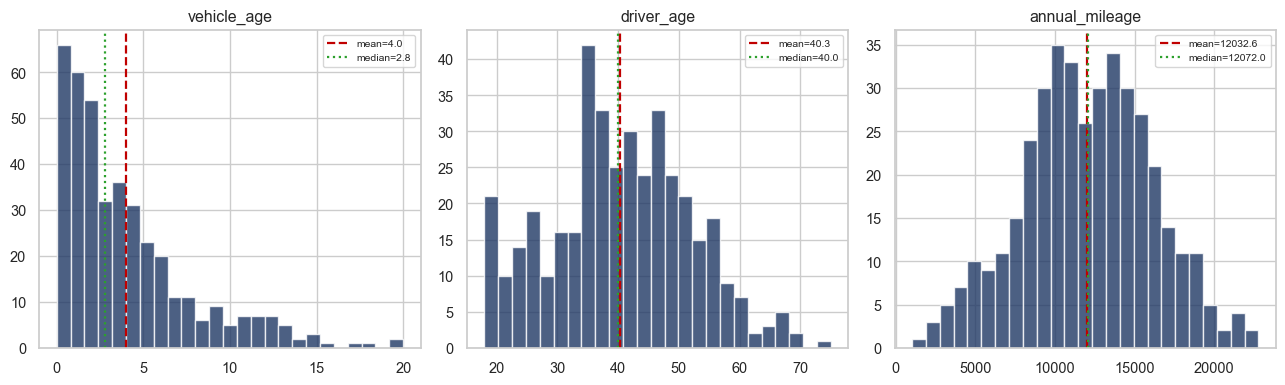

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['vehicle_age', 'driver_age', 'annual_mileage']):
    ax.hist(df[col], bins=25, color='#1F3864', alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='#C00000', linestyle='--', lw=1.6, label=f'mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#2CA02C', linestyle=':', lw=1.6, label=f'median={df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

**Observation:**
vehicle_age is skewed right, mean noticeably above median. driver_age and annual_mileage are close to normal. vehicle_age would be a candidate for a log transform in a linear model.

## Categorical Counts

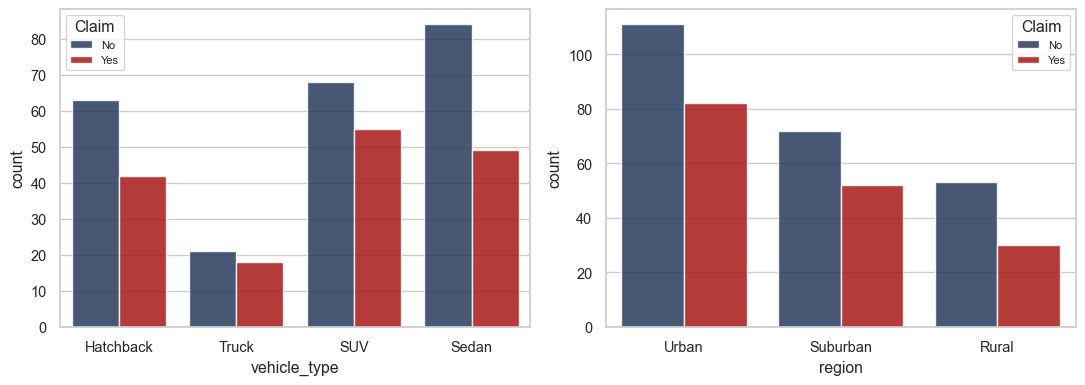

vehicle_type
Truck        0.462
SUV          0.447
Hatchback    0.400
Sedan        0.368
Name: claim_filed, dtype: float64
region
Urban       0.425
Suburban    0.419
Rural       0.361
Name: claim_filed, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='vehicle_type', hue='claim_filed', data=df, ax=axes[0],
              palette={0: '#1F3864', 1: '#C00000'}, alpha=0.85)
axes[0].legend(title='Claim', labels=['No', 'Yes'], fontsize=8)
sns.countplot(x='region', hue='claim_filed', data=df, ax=axes[1],
              palette={0: '#1F3864', 1: '#C00000'}, alpha=0.85)
axes[1].legend(title='Claim', labels=['No', 'Yes'], fontsize=8)
plt.tight_layout()
plt.show()

print(df.groupby('vehicle_type')['claim_filed'].mean().round(3).sort_values(ascending=False))
print(df.groupby('region')['claim_filed'].mean().round(3).sort_values(ascending=False))

**Observation:**
Truck has the fewest records, which makes the bar chart misleading on its own. Printed `groupby().mean()` to get the actual claim rate per category instead of reading bar heights.

## Class Balance

In [8]:
print(df['claim_filed'].value_counts())
print(f'Claim rate: {df["claim_filed"].mean()*100:.1f}%')

claim_filed
0    236
1    164
Name: count, dtype: int64
Claim rate: 41.0%


**Observation:**
Reasonably balanced. Checking this before anything else is now automatic, not an afterthought.

## Correlation Heatmap

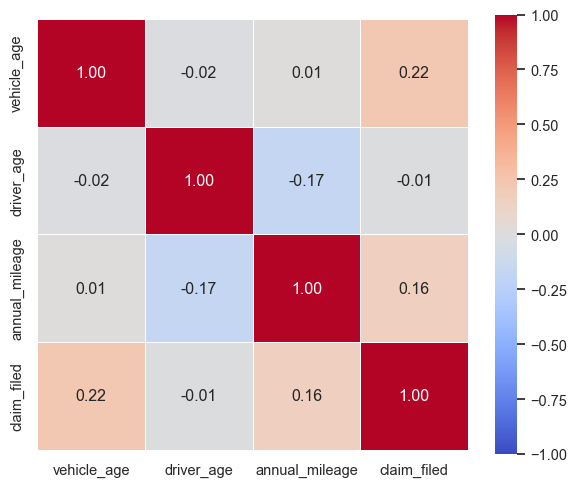

vehicle_age       0.22
annual_mileage    0.16
driver_age       -0.01
Name: claim_filed, dtype: float64


In [9]:
corr_cols = ['vehicle_age', 'driver_age', 'annual_mileage', 'claim_filed']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
plt.tight_layout()
plt.show()

print(corr_matrix['claim_filed'].drop('claim_filed').sort_values(ascending=False))

**Observation:**
vehicle_age has the strongest correlation with claim_filed, driver_age is negative — both consistent with how the data was generated.